In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import PIL.Image
import time

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

In [ ]:
content_path = tf.keras.utils.get_file(
    'turtle.jpg',
    'https://storage.googleapis.com/download.tensorflow.org/example_images/Green_Sea_Turtle_grazing_seagrass.jpg')

style_path = tf.keras.utils.get_file(
    'kandinsky.jpg',
    'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

print("Content image:", content_path)
print("Style image:", style_path)

In [ ]:
def load_img(path_to_img):
    max_dim = 512
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

def imshow(image, title=None):
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')

In [ ]:
content_image = load_img(content_path)
style_image = load_img(style_path)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')

plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')
plt.show()

In [ ]:
!pip install tensorflow_hub --quiet

In [ ]:
import tensorflow_hub as hub

hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')
stylized_image = hub_model(tf.constant(content_image), tf.constant(style_image))[0]

plt.figure(figsize=(8, 8))
imshow(stylized_image, 'Quick Stylized Result (TF-Hub model)')
plt.show()

In [ ]:
x = tf.keras.applications.vgg19.preprocess_input(content_image * 255)
x = tf.image.resize(x, (224, 224))
vgg = tf.keras.applications.VGG19(include_top=True, weights='imagenet')
prediction_probabilities = vgg(x)
print(prediction_probabilities.shape)

In [ ]:
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
print()
for layer in vgg.layers:
    print(layer.name)

In [ ]:
content_layers = ['block5_conv2']

style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

In [ ]:
def vgg_layers(layer_names):
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    outputs = [vgg.get_layer(name).output for name in layer_names]
    model = tf.keras.Model([vgg.input], outputs)
    return model

In [ ]:
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1] * input_shape[2], tf.float32)
    return result / num_locations

In [ ]:
class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        inputs = inputs * 255.0
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed_input)
        style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                           outputs[self.num_style_layers:])

        style_outputs = [gram_matrix(style_output) for style_output in style_outputs]

        content_dict = {content_name: value
                         for content_name, value
                         in zip(self.content_layers, content_outputs)}

        style_dict = {style_name: value
                       for style_name, value
                       in zip(self.style_layers, style_outputs)}

        return {'content': content_dict, 'style': style_dict}

extractor = StyleContentModel(style_layers, content_layers)

results = extractor(tf.constant(content_image))
print('Styles:')
for name, output in sorted(results['style'].items()):
    print("  ", name)
    print("    shape: ", output.numpy().shape)

print("\nContents:")
for name, output in sorted(results['content'].items()):
    print("  ", name)
    print("    shape: ", output.numpy().shape)

In [ ]:
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

image = tf.Variable(content_image)

def clip_0_1(image):
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

style_weight = 1e-2
content_weight = 1e4

def style_content_loss(outputs):
    style_outputs = outputs['style']
    content_outputs = outputs['content']

    style_loss = tf.add_n([tf.reduce_mean((style_outputs[name] - style_targets[name])**2)
                            for name in style_outputs.keys()])
    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n([tf.reduce_mean((content_outputs[name] - content_targets[name])**2)
                              for name in content_outputs.keys()])
    content_loss *= content_weight / num_content_layers

    loss = style_loss + content_loss
    return loss

In [ ]:
@tf.function()
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        loss = style_content_loss(outputs)

    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(clip_0_1(image))
    return loss

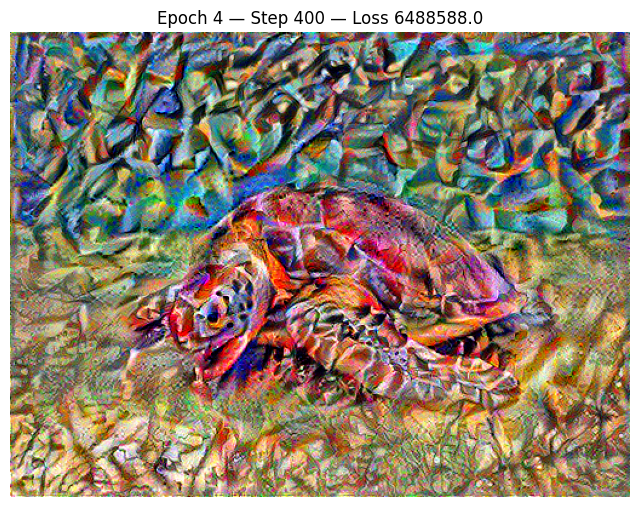

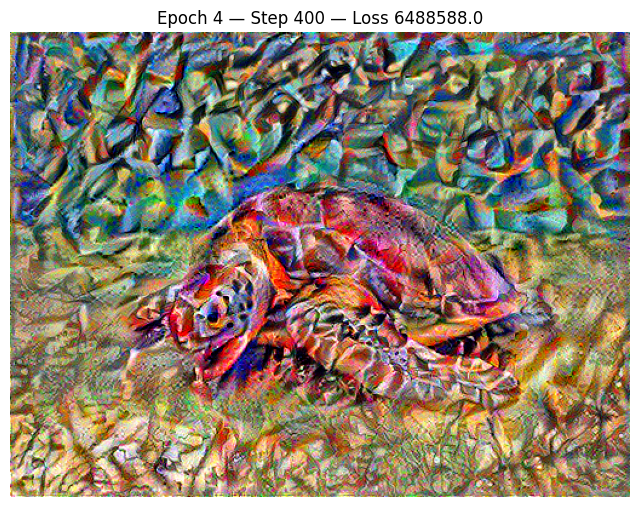

Train step: 400
Train step: 400
........................................................................................................................................................................................

In [ ]:
import IPython.display as display

epochs = 10
steps_per_epoch = 100

start = time.time()
step = 0
for n in range(epochs):
    for m in range(steps_per_epoch):
        step += 1
        loss = train_step(image)
        print('.', end='', flush=True)
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 8))
    imshow(image.read_value(), f"Epoch {n+1} — Step {step} — Loss {loss:.1f}")
    plt.show()
    print(f"Train step: {step}")

end = time.time()
print(f"Total time: {end-start:.1f}s")

In [ ]:
def high_pass_x_y(image):
    x_var = image[:, :, 1:, :] - image[:, :, :-1, :]
    y_var = image[:, 1:, :, :] - image[:, :-1, :, :]
    return x_var, y_var

x_deltas, y_deltas = high_pass_x_y(image)

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
imshow(clip_0_1(2*y_deltas+0.5), "Horizontal Deltas: Styled")
plt.subplot(2, 2, 2)
imshow(clip_0_1(2*x_deltas+0.5), "Vertical Deltas: Styled")
plt.show()

total_variation_weight = 30

def total_variation_loss(image):
    x_deltas, y_deltas = high_pass_x_y(image)
    return tf.reduce_sum(tf.abs(x_deltas)) + tf.reduce_sum(tf.abs(y_deltas))

In [ ]:
@tf.function()
def train_step_tv(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        loss = style_content_loss(outputs)
        loss += total_variation_weight * tf.image.total_variation(image)

    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(clip_0_1(image))
    return loss

In [ ]:
image = tf.Variable(content_image)
opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

epochs = 10
steps_per_epoch = 100

start = time.time()
step = 0
for n in range(epochs):
    for m in range(steps_per_epoch):
        step += 1
        loss = train_step_tv(image)
        print('.', end='', flush=True)
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 8))
    imshow(image.read_value(), f"Final (with TV loss) — Epoch {n+1} — Step {step}")
    plt.show()
    print(f"Train step: {step}")

end = time.time()
print(f"Total time: {end-start:.1f}s")

In [ ]:
def tensor_to_image(tensor):
    tensor = tensor * 255
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor) > 3:
        assert tensor.shape[0] == 1
        tensor = tensor[0]
    return PIL.Image.fromarray(tensor)

final_image = tensor_to_image(image)
final_image.save('stylized_output.png')
final_image

In [ ]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
imshow(content_image, 'Content Image')
plt.subplot(1, 3, 2)
imshow(style_image, 'Style Image')
plt.subplot(1, 3, 3)
imshow(image.read_value(), 'Stylized Output')
plt.show()

## Summary
- Implemented Neural Style Transfer using a pre-trained VGG19 network as a fixed feature extractor.
- Used block5_conv2 for content representation and five layers (block1_conv1 through block5_conv1) for style representation.
- Style is captured using the Gram matrix of feature maps, representing texture/pattern correlations.
- Combined content loss and style loss, optimized directly on the output image's pixels via gradient descent.
- Added total variation loss to reduce noise and produce a smoother final result.
- Also compared against a fast pre-trained TF-Hub arbitrary style transfer model as a baseline.